--- Starting SVM (SVR) Consumption Forecasting ---
--- With Population and Income Growth as Input Features ---
Training data: 96 months (2015-01-01 00:00:00 to 2022-12-01 00:00:00)
Test data: 36 months (2023-01-01 00:00:00 to 2025-12-01 00:00:00)
Optimization: Searching for best SVR parameters...
Best Parameters Found: {'epsilon': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}
Validation MAPE: 0.10%
Process complete. Figure saved at: ..\figuras\figure-svm-forecast-validation-multi.pdf


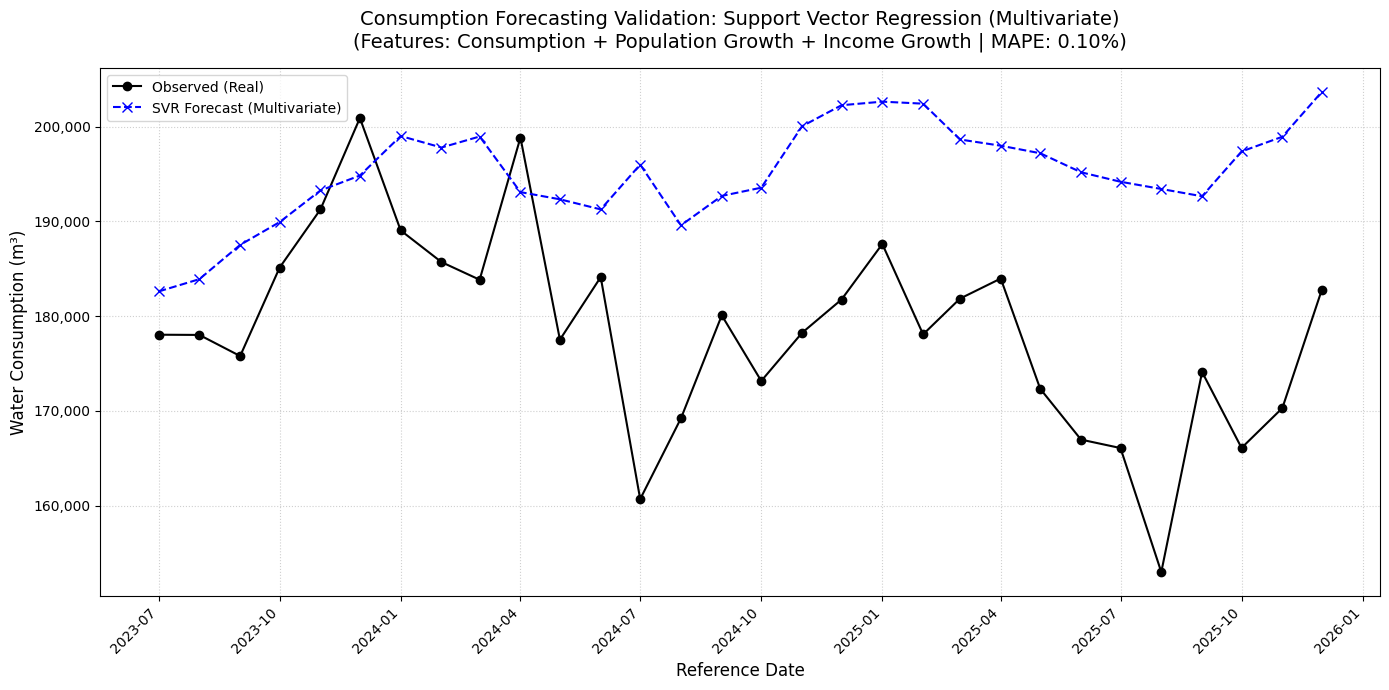

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = '..'
INPUT_FILE = os.path.join(BASE_PATH, 'includes','dados', 'Tabela_consumo_Itapua_120m.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-svm-forecast-validation-multi.pdf'

# ==========================================
# 1.1 Growth Rates Vectors (2016-2025)
# ==========================================
taxas_crescimento_mensal = [
    0.00034,  # 2016
    0.00034,  # 2017
    0.00035,  # 2018
    0.00034,  # 2019
    0.00032,  # 2020
    0.00030,  # 2021
    0.00029,  # 2022
    0.00027,  # 2023
    0.00025,  # 2024
    0.00023   # 2025
]

percentuais_aumento_renda = [
    -0.040694617,  # 2016
    0.005083616,   # 2017
    0.005261762,   # 2018
    0.009585339,   # 2019
    -0.045615004,  # 2020
    0.039183815,   # 2021
    0.021387542,   # 2022
    0.004332235,   # 2023
    0.045954924,   # 2024
    0.011194       # 2025
]

def create_multivariate_dataset(data, look_back=1):
    """
    Converts multivariate time series data into a supervised learning format.
    data: DataFrame with columns ['consumption', 'pop_growth', 'income_growth']
    Returns X (features) and Y (target)
    """
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)].values.flatten())
        Y.append(data.iloc[i + look_back]['consumption'])
    return np.array(X), np.array(Y)

def main():
    print("--- Starting SVM (SVR) Consumption Forecasting ---")
    print("--- With Population and Income Growth as Input Features ---")

    # ==========================================
    # 2. Data Loading and Preprocessing
    # ==========================================
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file not found at {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    
    dates = df_aggregated['AM_REFERENCIA']
    consumption = df_aggregated['HCLQTCON'].values
    
    # ==========================================
    # 3. Create Multivariate Dataset
    # ==========================================
    pop_growth_monthly = []
    inc_growth_monthly = []
    
    # 2015 (use 2016 rates as baseline)
    pop_growth_monthly.extend([taxas_crescimento_mensal[0]] * 12)
    inc_growth_monthly.extend([percentuais_aumento_renda[0]] * 12)
    
    # 2016-2025
    for i in range(10):
        pop_growth_monthly.extend([taxas_crescimento_mensal[i]] * 12)
        inc_growth_monthly.extend([percentuais_aumento_renda[i]] * 12)
    
    n_months = len(consumption)
    pop_growth_monthly = pop_growth_monthly[:n_months]
    inc_growth_monthly = inc_growth_monthly[:n_months]
    
    df_multivariate = pd.DataFrame({
        'date': dates,
        'consumption': consumption,
        'pop_growth': pop_growth_monthly,
        'income_growth': inc_growth_monthly
    })
    
    # ==========================================
    # 4. Data Normalization
    # ==========================================
    scaler = MinMaxScaler(feature_range=(0, 1))
    features_to_scale = ['consumption', 'pop_growth', 'income_growth']
    df_multivariate[features_to_scale] = scaler.fit_transform(
        df_multivariate[features_to_scale]
    )
    
    # Train-Test Split (Chronological)
    train_mask = (df_multivariate['date'] >= '2015-01-01') & (df_multivariate['date'] <= '2022-12-01')
    test_mask = (df_multivariate['date'] >= '2023-01-01') & (df_multivariate['date'] <= '2025-12-01')
    
    train_data = df_multivariate[train_mask].copy()
    test_data = df_multivariate[test_mask].copy()
    
    print(f"Training data: {len(train_data)} months ({train_data['date'].min()} to {train_data['date'].max()})")
    print(f"Test data: {len(test_data)} months ({test_data['date'].min()} to {test_data['date'].max()})")

    look_back = 6
    
    # Create dataset with all features
    X_train, Y_train = create_multivariate_dataset(
        train_data[['consumption', 'pop_growth', 'income_growth']], 
        look_back
    )
    X_test, Y_test = create_multivariate_dataset(
        test_data[['consumption', 'pop_growth', 'income_growth']], 
        look_back
    )
    
    if len(X_train) == 0 or len(X_test) == 0:
        print("Error: Insufficient data. Please reduce look_back.")
        return

    # ==========================================
    # 5. Hyperparameter Tuning (GridSearch)
    # ==========================================
    print("Optimization: Searching for best SVR parameters...")
    param_grid = {
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.1],
        'epsilon': [0.01, 0.1, 0.001]
    }
    
    svr = SVR()
    grid_search = GridSearchCV(svr, param_grid, cv=3, 
                               scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
    grid_search.fit(X_train, Y_train)
    
    best_params = grid_search.best_params_
    print(f"Best Parameters Found: {best_params}")
    
    # Train final model with optimized parameters
    best_svr = SVR(**best_params)
    best_svr.fit(X_train, Y_train)
    
    # ==========================================
    # 6. Predictions and Evaluation
    # ==========================================
    predictions_scaled = best_svr.predict(X_test)
    
    # Inverse transform predictions to original scale
    predictions_dummy = np.zeros((len(predictions_scaled), 3))
    predictions_dummy[:, 0] = predictions_scaled
    predictions = scaler.inverse_transform(predictions_dummy)[:, 0]
    
    # Inverse transform actual values
    Y_test_dummy = np.zeros((len(Y_test), 3))
    Y_test_dummy[:, 0] = Y_test
    Y_test_original = scaler.inverse_transform(Y_test_dummy)[:, 0]
    
    # Retrieve dates for the test window
    test_dates = test_data['date'].iloc[look_back:].values
    
    # Calculate MAPE metric
    mape_value = mape(Y_test_original, predictions)
    print(f"Validation MAPE: {mape_value:.2f}%")

    # ==========================================
    # 7. Visualization and Export
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(test_dates, Y_test_original, label='Observed (Real)', color='black', 
            marker='o', linestyle='-', linewidth=1.5, markersize=6)
    ax.plot(test_dates, predictions, label='SVR Forecast (Multivariate)', color='blue', 
            marker='x', linestyle='--', linewidth=1.5, markersize=7)

    # Formatting
    ax.set_title(f"Consumption Forecasting Validation: Support Vector Regression (Multivariate)\n"
                 f"(Features: Consumption + Population Growth + Income Growth | MAPE: {mape_value:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    # Thousands separator for Y axis
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()

    # Save to PDF for LaTeX integration
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Process complete. Figure saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()